In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from torch.utils.data import TensorDataset, DataLoader
from typing import Optional, Callable, Dict
from tqdm.notebook import tqdm, trange
from torchvision import datasets, transforms
import numpy as np
import plotly.express as px
import random

For debugging and reproducibility I fix the seeds, removing the stochastic randomness component.
Then, if I have NVIDIA GPUs I use CUDA; if I have Apple Silicon I use MPS ([Metal Performance Shaders](https://en.wikipedia.org/wiki/Metal_(API))). If none of the previous 2 are possible I resort to CPU.

In [ ]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(0)
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("device:", device)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("device:", device)

## Initial dataset and data loader
To generate my data (points on a circle) I sample the angle $\theta$ from a uniform over $[0,2\pi]$ and use polar coordinates with a radius $r$:
- $x = r\cdot cos(\theta)$
- $y = r\cdot sin(\theta)$

The DataLoader will shuffle my data at the beginning of each epoch, divide them into batches and make them an iterator. As an input it needs an object implementing Dataset interface (which has the methods to get the total count of my data and to extract a specific record): this is done by TensorDataset which is an adapter of the tensor returned by my `generate_circles` method

In [ ]:
"""
returns a tensor of shape (num_samples, 2) containing points sampled from a circle of given radius
"""
def generate_circles(num_samples=5000, radius=2.0):
    theta = torch.rand(num_samples) * 2 * math.pi
    x = radius * torch.cos(theta)
    y = radius * torch.sin(theta)
    return torch.stack((x, y), dim=-1)

circles = generate_circles(num_samples=10000)
train_dl = DataLoader(TensorDataset(circles), batch_size=64, shuffle=True) 

## First network: unconditional score Multi-Layer Perceptron
My first network is a MLP that is composed of fully connected layers (`nn.Linear`). For convenience and code readability I implemented a for loop adding linear layers + activation, even if with any number of hidden layer my full architecture will initially have 2 consecutive linear layers (two linear transformations collapse into one linear transformation). My last layer is still linear since I want to get 2-dimensional tensors having values on all $\mathbb{R}$ (yeah, apart digit approximation of course)

- Input: a point $(x,y)$; 
- Output: the predicted noise $(\epsilon_x, \epsilon_y)$

From the predicted noise I'm defining a direction because when we subtract it we move closer to the clean data. 

In [ ]:
class ScoreMLPPoints(nn.Module):
    def __init__(self, num_layers: int, hidden_dim: int, 
                 activation: Callable[[torch.Tensor], torch.Tensor]) -> None:
        super().__init__()
        self.first_layer = nn.Linear(in_features=2, out_features=hidden_dim)
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            self.layers.append(
                nn.Linear(in_features=hidden_dim, out_features=hidden_dim)
            )
        self.activation = activation
        self.last_layer = nn.Linear(in_features=hidden_dim, out_features=2)

    def forward(self, meshgrid: torch.Tensor) -> torch.Tensor:
        out = meshgrid
        out = self.first_layer(out)
        for layer in self.layers:
            out = layer(out)
            out = self.activation(out)
        out = self.last_layer(out)
        return out

Training parameters

In [ ]:
num_layers = 3
hidden_dim = 128
sigma = 0.3
epochs = 6#50

continua
## Model instantiation, activation and optimizer
For the activation function, in the course we've seen some ("relu", "leaky_relu", "elu", "sigmoid",  "tanh"). I avoid `sigmoid` and `tanh` for vanishing gradient problem. I chose `elu`

In [ ]:
model = ScoreMLPPoints(num_layers=num_layers, 
                       hidden_dim=hidden_dim, 
                       activation=torch.nn.functional.elu)
model = model.to(device)
opt = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in tqdm(range(epochs), desc="epoch"):
    model.train()
    epoch_loss = 0.0 
    num_batches = 0  
    for (xb,) in train_dl:
        x_orig = xb.to(device)
        noise = torch.randn_like(x_orig)
        # here I dirty the data with noise
        x_noisy = x_orig + sigma * noise
        noise_predicted = model(x_noisy)
        #I compute the mse loss
        loss = F.mse_loss(noise_predicted, noise)
        loss.backward()
        opt.step()
        opt.zero_grad()
        epoch_loss += loss.item()
        num_batches += 1
    # mean loss in epoch
    print(epoch, epoch_loss / num_batches)
    #if (epoch + 1) % 10 == 0 or epoch == 0:
    #    print(epoch, epoch_loss / num_batches)

Given the equations in the pdf I can get the score as a function of the noise.


- $\nabla_{\tilde{\mathbf{x}}} \log q_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x}) = \frac{1}{\sigma^2}(\mathbf{x} - \tilde{\mathbf{x}})$


- $\tilde{\mathbf{x}} = \mathbf{x} + \sigma \epsilon \implies \mathbf{x} - \tilde{\mathbf{x}} = -\sigma \epsilon$


Here:
* **$\mathbf{x}$** is the original data
* **$\tilde{\mathbf{x}}$** represents noisy data
* **$\sigma$** is the SD of the Gaussian noise
* **$\epsilon$** is the standard Gaussian noise vector that will dirty my data
* **$q_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x})$** is the conditional probability distribution of the noisy data given the clean data and will model the noise corruption process.
* **$\nabla_{\tilde{\mathbf{x}}}$**: the gradient is computed wrt the noisy data and provides the direction of change


In the end I get
$$\nabla_{\tilde{\mathbf{x}}} \log q_\sigma(\tilde{\mathbf{x}} \mid \mathbf{x}) = \frac{-\sigma \epsilon}{\sigma^2} = -\frac{\epsilon}{\sigma}$$


Then I implement Langevin dynamics `x_langevin` from the following equation
$$\tilde{\mathbf{x}}^k = \tilde{\mathbf{x}}^{k-1} + \frac{\lambda_i}{2} \mathbf{s}_\theta(\tilde{\mathbf{x}}^{k-1}, \sigma_i) + \sqrt{\lambda_i}\mathbf{z}^k$$


where at each step $k$ I update the previous position $\tilde{\mathbf{x}}^{k-1}$ moving along the direction of the score with a step length scaled by $\lambda_i$. A standard Gaussian vector $\mathbf{z}^k$ adds randomness to explore the space.

In [ ]:
# langevin sampling with snapshots
model.eval()
num_steps = 300
step_size = 0.01 
x_langevin = torch.randn(1000, 2, device=device) * 4.0
initial_noise_np = x_langevin.cpu().clone().numpy()
snapshots = {}
monitored_steps = [1, 10, 20, 50, 100, 300]
with torch.no_grad():
    for k in range(num_steps):
        pred_noise = model(x_langevin)
        score = - pred_noise / sigma
        # langevin dynamics step
        z = torch.randn_like(x_langevin)
        x_langevin = x_langevin + 0.5 * step_size * score + math.sqrt(step_size) * z
        current_step = k + 1
        if current_step in monitored_steps:
            snapshots[current_step] = x_langevin.cpu().numpy()
final_generated_np = x_langevin.cpu().numpy()

In [ ]:
#visualization
circles_np = circles.cpu().numpy()
def plot_2d_points(points, title, color):
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=points[:, 0], y=points[:, 1],
            mode='markers',
            marker=dict(size=4, color=color, opacity=0.6),
            name=title
        )
    )
    fig.update_layout(
        title=title, 
        xaxis=dict(range=[-6, 6]), 
        yaxis=dict(range=[-6, 6])
    )
    fig.show()
plot_2d_points(circles_np, "Original data", "lightgreen")
plot_2d_points(initial_noise_np, "Noise", "red")
plot_2d_points(final_generated_np, "Data generated", "orange")

Here I plot some steps of my data generation process

In [ ]:
plot_2d_points(initial_noise_np, "Step 0: Pure Noise", "red")
for step in monitored_steps:
    plot_2d_points(
        snapshots[step],
        title=f"Step {step}: Inversion Process",
        color="orange"
    )

In [ ]:
#better representation in a grid
all_steps = monitored_steps
titles = [f"Step {step}" for step in all_steps]


fig = make_subplots(rows=2, cols=3, subplot_titles=titles)


for idx, step in enumerate(all_steps):
    row = (idx // 3) + 1
    col = (idx % 3) + 1
    points = initial_noise_np if step == 0 else snapshots[step]




    fig.add_trace(
        go.Scatter(
            x=points[:, 0], y=points[:, 1],
            mode='markers',
            marker=dict(size=3, color="orange", opacity=0.6),
            showlegend=False
        ),
        row=row, col=col
    )


fig.update_xaxes(range=[-6, 6])
fig.update_yaxes(range=[-6, 6])


fig.show()

Let's see if it generalizes: let's generate sinusoids

In [ ]:
def sines(num_samples=5000, amp=1.0, freq=1.0):
    theta = torch.rand(num_samples) * 2 * math.pi
    y = amp * torch.sin(freq * theta)
   

    return torch.stack((theta, y), dim=-1)


x_clean_sine = sines(num_samples=10000)
print(x_clean_sine.shape) 

train_ds_sine = TensorDataset(x_clean_sine)
train_dl_sine = DataLoader(train_ds_sine, batch_size=64, shuffle=True) 

In [ ]:
#initial state and training parameters
model = ScoreMLP2D(num_layers=3, hidden_dim=128, activation=torch.nn.functional.elu)
model = model.to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
sigma = 0.3

epochs = 21
losses_h = []
for epoch in tqdm(range(epochs), desc="epoch"):
    model.train()
    epoch_loss = 0.0 

    num_batches = 0  

    for (xb,) in train_dl_sine:
        x_clean = xb.to(device)
        noise = torch.randn_like(x_clean)
        # here I dirty the data with noise
        x_noisy = x_clean + sigma * noise
        pred_noise = model(x_noisy)
        #I compute the mse loss
        loss = F.mse_loss(pred_noise, noise)
        loss.backward()
        opt.step()
        opt.zero_grad()
        epoch_loss += loss.item()
        num_batches += 1




    # mean loss in epoch
    mean_epoch_loss = epoch_loss / num_batches
    losses_h.append(mean_epoch_loss)
    print(epoch, mean_epoch_loss)
    #if (epoch + 1) % 10 == 0 or epoch == 0:
    #    print(epoch, epoch_loss / num_batches)
   

# just some monitoring
min_loss_index = losses_h.index(min(losses_h))
print(f"Minimum loss of {losses_h[min_loss_index]:.6f} at epoch {min_loss_index}")
#loss plot
loss_fig = go.Figure()
loss_fig.add_trace(
    go.Scatter(
        x=list(range(epochs)),

        y=losses_h,

        mode='lines+markers',

        name='MSE Loss',
        line=dict(color='deepskyblue', width=2)
    )
)
loss_fig.update_layout(
    title="Training Loss",
    xaxis_title="Epoch",
    yaxis_title="MSE Loss"
)
loss_fig.show()


# langevin sampling with snapshots
model.eval()
num_steps = 1000
step_size = 0.01 


x_langevin = torch.randn(1000, 2, device=device) * 4.0

initial_noise_np = x_langevin.cpu().clone().numpy()


snapshots = {}
monitored_steps = [1, 10, 20, 50, 100, 300, 500, 1000]


with torch.no_grad():
    for k in range(num_steps):
        pred_noise = model(x_langevin)
        score = - pred_noise / sigma




        # langevin dynamics step
        z = torch.randn_like(x_langevin)
        x_langevin = x_langevin + 0.5 * step_size * score + math.sqrt(step_size) * z




        current_step = k + 1
        if current_step in monitored_steps:
            snapshots[current_step] = x_langevin.cpu().numpy()


final_generated_np = x_langevin.cpu().numpy()
all_steps =  monitored_steps
titles = [f"Step {step}" for step in all_steps]


fig = make_subplots(rows=2, cols=4, subplot_titles=titles)


for idx, step in enumerate(all_steps):
    row = (idx // 4) + 1
    col = (idx % 4) + 1
    points = initial_noise_np if step == 0 else snapshots[step]




    fig.add_trace(
        go.Scatter(
            x=points[:, 0], y=points[:, 1],
            mode='markers',
            marker=dict(size=3, color="orange", opacity=0.6),
            showlegend=False
        ),
        row=row, col=col
    )


fig.update_xaxes(range=[-6, 6])
fig.update_yaxes(range=[-6, 6])


fig.show()

## With different values of $\sigma$

In [ ]:
## see torch.nn.functional.elu vs F.elu
sigmas = [0.1, 0.3, 0.8]
epochs = 21
my_models = {}
my_losses = {}
def energy(y_pred, y_true):
    return torch.nn.functional.mse_loss(y_pred, y_true)
for sigma in sigmas:
    print(f"RUNNING EXPERIMENT WITH SIGMA = {sigma} ")
    # init
    model = ScoreMLP2D(num_layers=3, hidden_dim=128, activation=torch.nn.functional.elu )
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=0.001)
    losses_h = []
    # training
    for epoch in tqdm(range(epochs), desc=f"Training (sigma={sigma})"):
        model.train()
        epoch_loss = 0.0
        samples_nr = 0
        for (xb,) in train_dl_sine:
            x_clean = xb.to(device)
            noise = torch.randn_like(x_clean)
            x_noisy = x_clean + sigma * noise
            pred_noise = model(x_noisy)
            loss = energy(pred_noise, noise)
            loss.backward()
            opt.step()
            opt.zero_grad()
            epoch_loss += loss.item() * len(x_clean)
            samples_nr += len(x_clean)
        mean_epoch_loss = epoch_loss / samples_nr
        losses_h.append(mean_epoch_loss)
    my_models[sigma] = model.state_dict()
    my_losses[sigma] = losses_h
    min_loss_idx = losses_h.index(min(losses_h))
    print(f"[Sigma {sigma}] min loss {losses_h[min_loss_idx]:.6f} at epoch {min_loss_idx}")
    # training loss plot
    loss_fig = go.Figure()
    loss_fig.add_trace(
        go.Scatter(
            x=list(range(epochs)),
            y=losses_h,
            mode='lines+markers',
            name=f'MSE Loss (sigma={sigma})',
            line=dict(color='deepskyblue', width=2)
        )
    )
    loss_fig.update_layout(
        title=f"Training Loss Curve (Sigma = {sigma})",
        xaxis_title="Epoch", yaxis_title="MSE Loss"
    )
    loss_fig.show()
    # langevin sampling
    model.eval()
    num_steps = 1000
    step_size = 0.01
    x_langevin = torch.randn(1000, 2, device=device) * 4.0
    snapshots = {}
    monitored_steps = [1, 10, 20, 50, 100, 300, 500, 1000]
    with torch.no_grad():
        for k in range(num_steps):
            pred_noise = model(x_langevin)
            score = - pred_noise / sigma
            z = torch.randn_like(x_langevin)
            x_langevin = x_langevin + 0.5 * step_size * score + math.sqrt(step_size) * z
            current_step = k + 1
            if current_step in monitored_steps:
                snapshots[current_step] = x_langevin.cpu().numpy()
    all_steps = monitored_steps
    titles = [f"Step {step}" for step in all_steps]
    grid_fig = make_subplots(rows=2, cols=4, subplot_titles=titles)
    for idx, step in enumerate(all_steps):
        row = (idx // 4) + 1
        col = (idx % 4) + 1
        points = snapshots[step]
        grid_fig.add_trace(
            go.Scatter(
                x=points[:, 0], y=points[:, 1],
                mode='markers',
                marker=dict(size=3, color="orange", opacity=0.6),
                showlegend=False
            ),
            row=row, col=col
        )
    grid_fig.update_layout(
        title_text=f"Langevin Inversion Grid (Sigma = {sigma})"
    )
    grid_fig.update_xaxes(range=[-6, 6])
    grid_fig.update_yaxes(range=[-6, 6])
    grid_fig.show()

## Let's go NCSNs!
Since basic score estimation is unreliable in low density regions now we're conditioning on $\sigma$ instead of having it fixed. Then I use Langevin dynamics running a schedule to decrease sigma progressively.

In [ ]:
class CondMLP(nn.Module):
    def __init__(self,
                num_layers: int,
                hidden_dim: int,
                activation: Callable[[torch.Tensor], torch.Tensor]) -> None:
        super().__init__()
        self.first_layer = nn.Linear(in_features=2, out_features=hidden_dim)
        self.sigma_layer1 = nn.Linear(in_features=1, out_features=hidden_dim)
        self.sigma_layer2 = nn.Linear(in_features=hidden_dim, out_features=hidden_dim)
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            self.layers.append(
                nn.Linear(in_features=hidden_dim, out_features=hidden_dim)
            )
        self.activation = activation
        self.last_layer = nn.Linear(in_features=hidden_dim, out_features=2)
    def forward(self, meshgrid: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
        out = meshgrid
        out = self.first_layer(out)
        #inject noise
        h_sigma = self.sigma_layer2(self.activation(self.sigma_layer1(sigma)))
        out += h_sigma
        out = self.activation(out)
        for layer in self.layers:
            out = layer(out)
            out = self.activation(out)
        out = self.last_layer(out)
        return out

In [ ]:
#noise schedule
L = 8 

sigma_max = 4.0
sigma_min = 0.05
sigmas = torch.exp(torch.linspace(math.log(sigma_max), math.log(sigma_min), L)).to(device)
model = CondMLP(num_layers=3, hidden_dim=128, activation=torch.nn.functional.elu).to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
epochs = 30
losses_h = []
#training
for epoch in tqdm(range(epochs), desc="Training NCSN"):
    model.train()
    epoch_loss = 0.0 

    samples_nr = 0  

    for (xb,) in train_dl_sine:
        x_clean = xb.to(device)
        batch_size = x_clean.shape[0]
        indices = torch.randint(0, L, (batch_size,), device=device)
        batch_sigmas = sigmas[indices].view(-1, 1)

        noise = torch.randn_like(x_clean)
        x_noisy = x_clean + batch_sigmas * noise
        pred_noise = model(x_noisy, batch_sigmas)
        loss = F.mse_loss(pred_noise, noise)
        loss.backward()
        opt.step()
        opt.zero_grad()
        epoch_loss += loss.item() * len(x_clean)
        samples_nr += len(x_clean)
    losses_h.append(epoch_loss / samples_nr)
print(f"Final loss: {losses_h[-1]:.6f}")

In [ ]:
# annealed langevin sampling
model.eval()
steps_per_scale = 125

epsilon = 0.005      

x_langevin = torch.randn(1000, 2, device=device) * sigmas[0]
snapshots = {}
snapshot_titles = []
with torch.no_grad():
    for i, sig in enumerate(sigmas):
        step_size = epsilon * (sig / sigmas[-1])**2
        for k in range(steps_per_scale):
            batch_sig = torch.full((1000, 1), sig.item(), device=device)
            pred_noise = model(x_langevin, batch_sig)
            score = -pred_noise / sig
            z = torch.randn_like(x_langevin)
            x_langevin = x_langevin + 0.5 * step_size * score + math.sqrt(step_size) * z
        title = f"Scale {i+1} (sigma={sig:.2f})"
        snapshots[title] = x_langevin.cpu().numpy()
        snapshot_titles.append(title)

In [ ]:
#viz
fig = make_subplots(rows=2, cols=4, subplot_titles=snapshot_titles)
for idx, (title, points) in enumerate(snapshots.items()):
    row = (idx // 4) + 1
    col = (idx % 4) + 1
    fig.add_trace(
        go.Scatter(
            x=points[:, 0], y=points[:, 1],
            mode='markers',
            marker=dict(size=3, color="orange", opacity=0.6),
            showlegend=False
        ),
        row=row, col=col
    )
fig.update_layout(title_text="Annealed Langevin Dynamics (NCSN)")
fig.update_xaxes(range=[-6, 6])
fig.update_yaxes(range=[-6, 6])
fig.show()

## Diffusion Probabilistic Models

DPMs are based on a Markov Chain made by a sequence of states. Starting from a clean sample taken from the true distribution the forward process adds Gaussian noise for $T=1000$ steps. The main properties of MC is that the future is independent from the past given the present and in this case the final state will be a standard Gaussian distribution (pure noise).
Data generation is allowed by reverting this process: starting from random noise an update rule iteratively denoise it untill we get to new data. In each transition some random noise is added to explore the space of the data.
Since the network has no information on the temporal progression and a simple discrete integer timestep won't add much expressivity, that same timestep is transformed into sines and cosines, continuous functions with good properties as we will see.

## SinusoidalPositionEmbeddings




As we've seen in transformers architectures tokens are processed in parallel, so order is not tracked. Sentences as "Luca slaps Giovanni" and "Giovanni slaps Luca" are considered the same. In the paper "Attention is all you need" to track token order positional encodings (PEs) are injected into the encoder and decoder adding them to the input embeddings. PEs are implemented from sine and cosine functions with different frequencies. They have good properties: since they're boundend in $[-1, 1]$ they avoid numerical explosion; being periodical they can manage variable length sequences; the token relative distance is constant either if I consider tokens 1-2 or 2000-2001


- $PE_{(pos,\, 2i)} = \sin\left(\frac{pos}{10000^{\frac{2i}{d_m}}}\right)$


- $PE_{(pos,\, 2i+1)} = \cos\left(\frac{pos}{10000^{\frac{2i}{d_m}}}\right)$


where $pos$ is the token position in the sequence and $d_m$ is the embedding space dimension.


*Sources*
- [Attention is all you need](https://arxiv.org/pdf/1706.03762)
- [Sinusoidal positional encodings](https://medium.com/@pranay.janupalli/understanding-sinusoidal-positional-encoding-in-transformers-26c4c161b7cc)

In [ ]:
T = 1000
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sigmas = torch.sqrt(betas)

def make_averager():
    count = 0
    total = 0

    def averager(new_value):
        nonlocal count, total
        if new_value is None:
            return total / count if count else float("nan")
        count += 1
        total += new_value
        return total / count

    return averager

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_a_bar_t = torch.sqrt(alphas_cumprod[t]).unsqueeze(-1)
    sqrt_one_minus_a_bar_t = torch.sqrt(1. - alphas_cumprod[t]).unsqueeze(-1)
    return sqrt_a_bar_t * x0 + sqrt_one_minus_a_bar_t * noise

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    #pos = time equivalently
    def forward(self, pos):
        half_dim = self.dim // 2
        inv_freq = 1.0 / (10000 ** (torch.arange(0, half_dim, device=pos.device).float() / half_dim))
        args = pos[:, None] * inv_freq[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    
class TimeEmbedding(nn.Module):
    def __init__(self, hidden_dim: int, activation: Callable):
        super().__init__()
        self.emb = SinusoidalPositionEmbeddings(hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.activation = activation
        
    def forward(self, time):
        h = self.emb(time)
        h = self.activation(self.fc1(h))
        return self.fc2(h)
    
class DPM(nn.Module):
    def __init__(self, num_layers: int, hidden_dim: int, activation: Callable):
        super().__init__()
        self.first_layer = nn.Linear(2, hidden_dim)
        self.time_mlp = TimeEmbedding(hidden_dim, activation)
        self.layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(num_layers)
        ])
        self.activation = activation
        self.last_layer = nn.Linear(hidden_dim, 2)
        
    def forward(self, x, time):
        h = self.activation(self.first_layer(x) + self.time_mlp(time))
        for layer in self.layers:
            h = layer(h)
            h = self.activation(h)
        return self.last_layer(h)

In [ ]:
model = DPM(num_layers=3, hidden_dim=128, activation=torch.nn.functional.elu).to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
epochs = 40
losses_h = []


for epoch in trange(epochs, desc="train epoch"):
    model.train()
    train_loss_averager = make_averager() 
    tqdm_iterator = tqdm(
        enumerate(train_dl_sine),
        total=len(train_dl_sine),
        desc="batch [loss: None]",
        leave=False,
    )
    for batch_idx, (xb,) in tqdm_iterator:
        x_clean = xb.to(device)
        batch_size = x_clean.shape[0]
        t = torch.randint(0, T, (batch_size,), device=device).long()
        noise = torch.randn_like(x_clean)
        x_noisy = q_sample(x_clean, t, noise)
        pred_noise = model(x_noisy, t.float())
        loss = F.mse_loss(pred_noise, noise)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss_averager(loss.item())
        tqdm_iterator.set_description(
            f"train batch [avg loss: {train_loss_averager(None):.3f}]"
        )
        tqdm_iterator.refresh()
        
    losses_h.append(train_loss_averager(None))
    print(
        f"Epoch: {epoch}\n"
        f"Train set: Average loss: {train_loss_averager(None):.4f}\n"
    )


print(f"Final Loss for DPM : {losses_h[-1]:.6f}")

In [ ]:
# I start from random noise and run the reverse diffusion process to generate samples
model.eval()
x_trajectory = torch.randn(1000, 2, device=device)
initial_noise_np = x_trajectory.cpu().numpy()

snapshots = {}
monitored_timesteps = [999, 700, 500, 300, 100, 50, 20, 0]

with torch.no_grad():
    for t_idx in reversed(range(T)):
        t_batch = torch.full((1000,), t_idx, device=device, dtype=torch.float)
        pred_noise = model(x_trajectory, t_batch)
        beta_t = betas[t_idx]
        alpha_t = alphas[t_idx]
        alpha_cumprod_t = alphas_cumprod[t_idx]
        #reparameterized mu
        mean_coef = 1.0 / torch.sqrt(alpha_t)
        noise_coef = beta_t / torch.sqrt(1.0 - alpha_cumprod_t)
        model_mean = mean_coef * (x_trajectory - noise_coef * pred_noise)
        #update step: noise added to all steps except the last one
        if t_idx > 0:
            z = torch.randn_like(x_trajectory)
            sigma_t = sigmas[t_idx]
            x_trajectory = model_mean + sigma_t * z
        else:
            x_trajectory = model_mean
        if t_idx in monitored_timesteps:
            snapshots[t_idx] = x_trajectory.cpu().numpy()

In [ ]:
#viz
grid_timesteps = sorted(monitored_timesteps, reverse=True)
titles = [f"t = {t}" for t in grid_timesteps]
fig = make_subplots(rows=2, cols=4, subplot_titles=titles)
for idx, t in enumerate(grid_timesteps):
    row = (idx // 4) + 1
    col = (idx % 4) + 1
    points = snapshots[t]
    fig.add_trace(
        go.Scatter(
            x=points[:, 0], y=points[:, 1],
            mode='markers',
            marker=dict(size=3, color="orange", opacity=0.6),
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    title_text="Discrete DDPM Backward Trajectory (t=999 to t=0)"
)
fig.update_xaxes(range=[-6, 6])
fig.update_yaxes(range=[-6, 6])
fig.show()

## Generation of handwritten digits (trainign from MNIST)

The forward process' goal is injecting noise into the original image, progressively increasing the variance $\beta_t$ over $T$ timesteps.

#### The reparametrization trick
To compute noisy state $x_t$ for any time $t$ starting from state $x_0$ normally we should compute all the preceding states since in a Markov Chain any states depends on the one before. The time complexity would be $O(T)$. Single step formula is:
$$x^{(t)} = \sqrt{1-\beta_t}x^{(t-1)} + \sqrt{\beta_t}\epsilon_{t-1}$$

introducing 2 support variables $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$ it becomes:
$$x^{(t)} = \sqrt{\alpha_t}x^{(t-1)} + \sqrt{1-\alpha_t}\epsilon_{t-1}$$

Now applying that formula $t$ times we get
$$x^{(t)} = \sqrt{\bar{\alpha}_t}x^{(0)} + \sqrt{1-\bar{\alpha}_t}\epsilon \quad \text{dove } \epsilon \sim \mathcal{N}(0, I)$$

The proof is inductive and uses the properties of Gaussians.

In [ ]:
T = 1000
beta0 = 1e-4
beta_end = 0.02
betas = torch.linspace(beta0, beta_end, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sigmas = torch.sqrt(betas)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_dl = DataLoader(mnist_ds, batch_size=64, shuffle=True)
activation_h = {
    "steps": [],
    "means": [],
    "stds": [],
    "mins": [],
    "maxs": []
}
def q_sample(x_start: torch.Tensor, t: torch.Tensor, noise: Optional[torch.Tensor] = None) -> torch.Tensor:
    if noise is None:
        noise = torch.randn_like(x_start)
    sqrt_a_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_a_cumprod_t = torch.sqrt(1. - alphas_cumprod[t]).view(-1, 1, 1, 1)
    return sqrt_a_cumprod_t * x_start + sqrt_one_minus_a_cumprod_t * noise

In [64]:
class UNet(nn.Module):
    def __init__(self, time_dim: int = 128) -> None:
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.te1 = nn.Linear(time_dim, 32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2)
        self.te2 = nn.Linear(time_dim, 64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2)
        self.te3 = nn.Linear(time_dim, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.te4 = nn.Linear(time_dim, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.te5 = nn.Linear(time_dim, 32)
        
        self.out = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        def inject_time(h: torch.Tensor, time_proj: nn.Linear) -> torch.Tensor:
            return h + time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = F.relu(inject_time(self.conv1(x), self.te1))
        x2 = F.relu(inject_time(self.conv2(x1), self.te2))
        x3 = F.relu(inject_time(self.conv3(x2), self.te3))
        x4 = F.relu(inject_time(self.up1(x3), self.te4))
        x4 = x4 + x2
        x5 = F.relu(inject_time(self.up2(x4), self.te5))
        x5 = x5 + x1
        return self.out(x5)

def fit(
    epochs: int,
    train_dl: DataLoader,
    model: nn.Module,
    opt: optim.Optimizer,
    device: str = "mps") -> list:#cuda
    losses_history = []
    for epoch in trange(epochs, desc="train epoch"):
        model.train()
        train_loss_averager = make_averager()
        tqdm_iterator = tqdm(
            enumerate(train_dl),
            total=len(train_dl),
            desc="train batch [avg loss: None]",
            leave=False,
        )
        for _, (xb, _) in tqdm_iterator:
            x_clean = xb.to(device)
            batch_size = x_clean.shape[0]
            t = torch.randint(0, T, (batch_size,), device=device).long()
            noise = torch.randn_like(x_clean)
            x_noisy = q_sample(x_clean, t, noise)
            opt.zero_grad()
            pred_noise = model(x_noisy, t.float())
            loss = F.mse_loss(pred_noise, noise)
            loss.backward()
            opt.step()
            train_loss_averager(loss.item())
            tqdm_iterator.set_description(
                f"train batch [avg loss: {train_loss_averager(None):.5f}]"
            )
            tqdm_iterator.refresh()
            
        epoch_loss = train_loss_averager(None)
        losses_history.append(epoch_loss)
        
        print(
            f"Epoch: {epoch + 1}\n"
            f"Train set: Average loss: {epoch_loss:.5f}\n"
        )
    return losses_history


def peak_into_activations(module, input, output):
    out_detached = output.detach().cpu()
    activation_h["means"].append(out_detached.mean().item())
    activation_h["stds"].append(out_detached.std().item())
    activation_h["mins"].append(out_detached.min().item())
    activation_h["maxs"].append(out_detached.max().item())
    
def plot_activation_trends(history):
    steps = list(range(len(history["means"])))
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(x=steps, y=history["maxs"], name="Max Activation", line=dict(color='rgba(0,255,0,0.4)', dash='dash')))
    fig.add_trace(go.Scatter(x=steps, y=history["mins"], name="Min Activation", line=dict(color='rgba(255,0,0,0.4)', dash='dash')))
    
    fig.add_trace(go.Scatter(x=steps, y=history["means"], name="Mean Activation", line=dict(color='blue', width=2)))
    
    fig.update_layout(
        title="Internal Activation Evolution (conv3 Layer)",
        xaxis_title="Training Step (Batch Iteration)",
        yaxis_title="Activation Value Scale",
        hovermode="x unified",
        template="plotly_dark"
    )
    fig.show()



In [ ]:
import torchvision

model = UNet(time_dim=128).to(device)
model.conv3.register_forward_hook(peak_into_activations)
opt = optim.Adam(model.parameters(), lr=1e-3)
epochs = 1#20
losses_h = fit(epochs=epochs, train_dl=train_dl, model=model, opt=opt, device=device)
model.eval()
n_samples = 16
x_trajectory = torch.randn(n_samples, 1, 28, 28, device=device)

with torch.no_grad():
    for t_idx in tqdm(reversed(range(T)), total=T, desc="Denoising Steps"):
        t_batch = torch.full((n_samples,), t_idx, device=device, dtype=torch.float)
        pred_noise = model(x_trajectory, t_batch)
        beta_t = betas[t_idx]
        alpha_t = alphas[t_idx]
        alpha_cumprod_t = alphas_cumprod[t_idx]
        mu_coefficient = 1. / torch.sqrt(alpha_t)
        noise_coef = beta_t / torch.sqrt(1. - alpha_cumprod_t)
        mu_theta = mu_coefficient * (x_trajectory - noise_coef * pred_noise)
        
        if t_idx > 0:
            z = torch.randn_like(x_trajectory)
            sigma_t = sigmas[t_idx]
            x_trajectory = mu_theta + sigma_t * z
        else:
            x_trajectory = mu_theta

new_imgs = ((x_trajectory.cpu() + 1) / 2.0).clamp(0, 1)
grid_img = torchvision.utils.make_grid(new_imgs, nrow=4)
grid_np = grid_img.numpy().transpose((1, 2, 0))
fig = px.imshow(
    grid_np, 
    title=f"DPM Generated Digits (epochs: {epochs})"
)
fig.show()

train epoch:   0%|          | 0/1 [00:00<?, ?it/s]

train batch [avg loss: None]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch: 1
Train set: Average loss: 0.08333



Denoising Steps:   0%|          | 0/1000 [00:00<?, ?it/s]

#### Conv3 activations plot
I chose to record the activations of this layer because it encoded the information in the smallest space ($28\times28$) and it's the layer which produce input to the decoder.

In first model activation fluctuate after first epoch from less than -13 to more than 8

In [72]:
plot_activation_trends(activation_h)

## First update: GroupNorm
Since a single batch can contain images with different levels of noise BatchNormalization would damage my model, so I use $GroupNorm(g,c)$, which standardizes inside a group of channels, to make activations stabler and try to avoid exploding/vanishing gradients. The number of channels $c$ must be divisible by the number of groups $g$. To choose the number of groups I needed to find a common divisor of the channels $32, 64, 128$ that was different from the maximum common divisor ($32$), since having 1 channel/group alone would collapse into InstanceNormalization that for computer vision tasks has worse performance-
Looking at the paper [Group Normalization](https://arxiv.org/pdf/1803.08494) I chose $8$ groups because it achieved the second best validation error after $32$ that I couldn't use as I explained before.
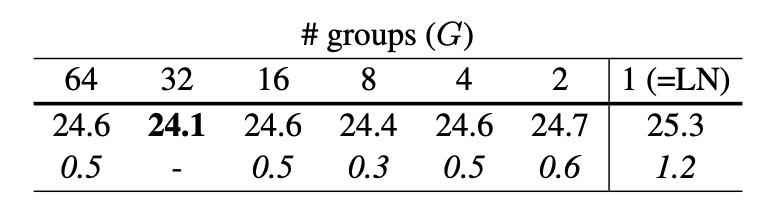

After having applied GroupNorm in the second model activations fluctuate after first epoch approximately in the range $(-5, +4]$

In [75]:
class UNetWithNorm(nn.Module):
    def __init__(self, time_dim: int = 128) -> None:
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.gn1 = nn.GroupNorm(8, 32)
        self.te1 = nn.Linear(time_dim, 32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2)
        self.gn2 = nn.GroupNorm(8, 64)
        self.te2 = nn.Linear(time_dim, 64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2)
        self.gn3 = nn.GroupNorm(8, 128)
        self.te3 = nn.Linear(time_dim, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.gn4 = nn.GroupNorm(8, 64)
        self.te4 = nn.Linear(time_dim, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.gn5 = nn.GroupNorm(8, 32)
        self.te5 = nn.Linear(time_dim, 32)
        
        self.out = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)
        
        def inject_time(h: torch.Tensor, time_proj: nn.Linear) -> torch.Tensor:
            return h + time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = F.relu(self.gn1(inject_time(self.conv1(x), self.te1)))
        x2 = F.relu(self.gn2(inject_time(self.conv2(x1), self.te2)))
        x3 = F.relu(self.gn3(inject_time(self.conv3(x2), self.te3)))
        
        x4 = F.relu(self.gn4(inject_time(self.up1(x3), self.te4)))
        x4 = x4 + x2
        
        x5 = F.relu(self.gn5(inject_time(self.up2(x4), self.te5)))
        x5 = x5 + x1
        
        return self.out(x5)

In [ ]:
#training[11:24<00:00, 34.18s/it]
#denoising[00:04<00:00, 271.06it/s]
activation_h2 = {
    "steps": [],
    "means": [],
    "stds": [],
    "mins": [],
    "maxs": []
}

def peak_into_activations2(module, input, output):
    out_detached = output.detach().cpu()
    activation_h2["means"].append(out_detached.mean().item())
    activation_h2["stds"].append(out_detached.std().item())
    activation_h2["mins"].append(out_detached.min().item())
    activation_h2["maxs"].append(out_detached.max().item())
    
model = UNetWithNorm(time_dim=128).to(device)
model.conv3.register_forward_hook(peak_into_activations2)
opt = optim.Adam(model.parameters(), lr=1e-3)
epochs = 20
losses_h = fit(epochs=epochs, train_dl=train_dl, model=model, opt=opt, device=device)
model.eval()
n_samples = 16
x_trajectory = torch.randn(n_samples, 1, 28, 28, device=device)

with torch.no_grad():
    for t_idx in tqdm(reversed(range(T)), total=T, desc="Denoising Steps"):
        t_batch = torch.full((n_samples,), t_idx, device=device, dtype=torch.float)
        pred_noise = model(x_trajectory, t_batch)
        beta_t = betas[t_idx]
        alpha_t = alphas[t_idx]
        alpha_cumprod_t = alphas_cumprod[t_idx]
        mu_coefficient = 1. / torch.sqrt(alpha_t)
        noise_coef = beta_t / torch.sqrt(1. - alpha_cumprod_t)
        mu_theta = mu_coefficient * (x_trajectory - noise_coef * pred_noise)
        
        if t_idx > 0:
            z = torch.randn_like(x_trajectory)
            sigma_t = sigmas[t_idx]
            x_trajectory = mu_theta + sigma_t * z
        else:
            x_trajectory = mu_theta

new_imgs = ((x_trajectory.cpu() + 1) / 2.0).clamp(0, 1)
grid_img = torchvision.utils.make_grid(new_imgs, nrow=4)
grid_np = grid_img.numpy().transpose((1, 2, 0))
fig = px.imshow(
    grid_np, 
    title=f"DPM Generated Digits (Epochs: {epochs})"
)
fig.show()
plot_activation_trends(activation_h2)

train epoch:   0%|          | 0/20 [00:00<?, ?it/s]

train batch [avg loss: None]:   0%|          | 0/938 [00:00<?, ?it/s]